# Week 3 – Day 5 – Hands-On Lab
## Heart Disease Prediction (End-to-End Mini-Project)

### Objective
Today is the Week 3 capstone. I'm building a complete ML pipeline on a dataset I haven't worked with before — Heart Disease UCI. The goal is to go from raw data all the way to a trained, evaluated model, making every decision based on what I actually find in the data.

---

## Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, roc_curve
)

---

## Load Data

In [25]:
df = pd.read_csv('data/heart_disease_uci.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**What I see:** 920 patients and 16 columns. A few things stand out immediately:

- `id` and `dataset` are not medical features — `id` is a row number and `dataset` is the hospital name. I'll drop both.
- `num` is the target — values range from 0 to 4 (disease severity). I'll convert it to binary: 0 = no disease, 1 = disease.
- Several columns are text categories (`sex`, `cp`, `restecg`) — they'll need encoding before any model can use them.
- `fbs` and `exang` are stored as True/False — I'll convert those to 1/0.

---

## Exploratory Data Analysis

### Structure

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


Several columns have fewer non-null values than 920, so there are missing values. I'll check the exact percentage next.

### Missing Values

In [27]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Missing values (%):")
print(missing_pct)

Missing values (%):
ca          66.4
thal        52.8
slope       33.6
fbs          9.8
oldpeak      6.7
trestbps     6.4
exang        6.0
thalch       6.0
chol         3.3
restecg      0.2
dtype: float64


**What I see:**
- `ca` (66.4%), `thal` (52.8%), `slope` (33.6%) — more than a third missing. Filling this many gaps would be guessing, not data. I'll drop all three.
- Everything else is under 10% — manageable with imputation.

### Target Distribution

Target value counts (original):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


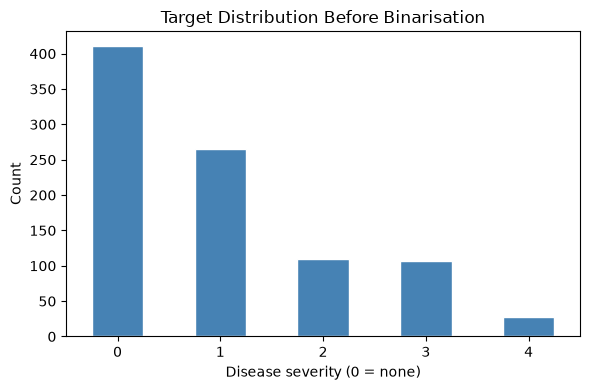

In [28]:
print("Target value counts (original):")
print(df['num'].value_counts().sort_index())

df['num'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white', figsize=(6, 4)
)
plt.xlabel("Disease severity (0 = none)")
plt.ylabel("Count")
plt.title("Target Distribution Before Binarisation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Most patients are labelled 0 (no disease). Severity levels 1–4 each represent some degree of disease — I'll collapse them all into 1 so this becomes a clean binary classification problem.

### Suspicious Zeros

In [29]:
# chol = 0 is physiologically impossible — treat as hidden missing values
print("chol zeros:", (df['chol'] == 0).sum(), "out of", len(df))
print("trestbps zeros:", (df['trestbps'] == 0).sum(), "out of", len(df))

chol zeros: 172 out of 920
trestbps zeros: 1 out of 920


`chol` has 172 zeros — a living person can't have zero cholesterol. These are missing values recorded as 0, same pattern I saw in the Pima Diabetes dataset in Week 3 Day 3. I'll replace them with NaN so the imputation step handles them properly.

### Numeric Distributions

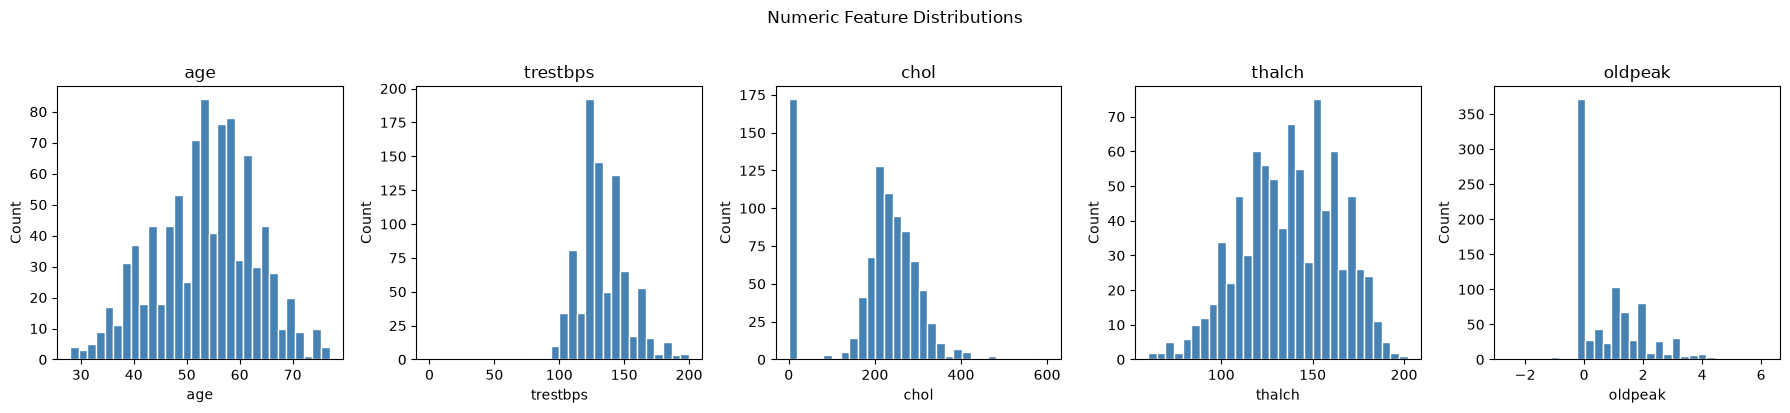

In [30]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

`oldpeak` is right-skewed — most patients have low ST depression, with a few high outliers. The others look roughly normal. Nothing extreme enough to change the modeling approach, but good to know before scaling.

### Class Balance Check

In [31]:
# after binarising — check if the classes are balanced
binary_target = (df['num'] > 0).astype(int)
print("Class balance (binary target):")
print(binary_target.value_counts())
print()
print(f"No disease: {(binary_target == 0).sum() / len(binary_target) * 100:.1f}%")
print(f"Disease:    {(binary_target == 1).sum() / len(binary_target) * 100:.1f}%")

Class balance (binary target):
num
1    509
0    411
Name: count, dtype: int64

No disease: 44.7%
Disease:    55.3%


After binarising: 44.7% no disease, 55.3% disease — reasonably balanced. Accuracy won't be as misleading here as it was with the Pima dataset (which was 65/35), but I'll still look at recall and F1 to judge the models properly.

---

## Clean the Data

Based on what I found in EDA, the cleaning plan is:
1. Replace `chol` zeros with NaN — they're hidden missing values, not real measurements
2. Drop `id` and `dataset` — not medical features
3. Drop `ca`, `thal`, `slope` — too much missing data (>33%)
4. Convert `num` to binary: 0 stays 0, anything above 0 becomes 1
5. Convert `fbs` and `exang` from True/False to 1/0

In [32]:
# step 1 — replace impossible chol zeros with NaN
df['chol'] = df['chol'].replace(0, np.nan)

# step 2 & 3 — drop non-feature and high-missing columns
df = df.drop(columns=['id', 'dataset', 'ca', 'thal', 'slope'])

# step 4 — convert target to binary
df['num'] = (df['num'] > 0).astype(int)

# step 5 — convert boolean columns to int
df['fbs']   = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})

print("Shape after cleaning:", df.shape)
print()
print("Target distribution after binarising:")
print(df['num'].value_counts())

Shape after cleaning: (920, 11)

Target distribution after binarising:
num
1    509
0    411
Name: count, dtype: int64


**Check — verify no unexpected columns remain:**

In [33]:
print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'num']


---

## Impute Remaining Missing Values

In [34]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
trestbps     59
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
dtype: int64


In [35]:
# numeric columns — fill with median (robust to outliers)
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col] = df[col].fillna(df[col].median())

# categorical/boolean — fill with mode
for col in ['fbs', 'restecg', 'exang']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum().sum(), "— all clear")

Missing values after imputation:
0 — all clear


---

## Correlation with Target

Before encoding, I check how numeric features correlate with the binary target — a quick way to spot which features might matter most.

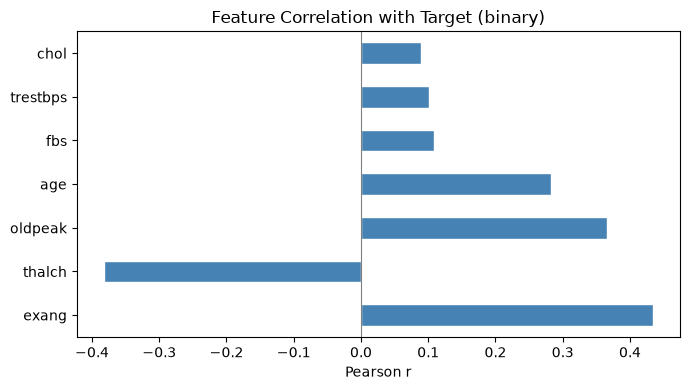

exang       0.434
thalch     -0.382
oldpeak     0.366
age         0.283
fbs         0.108
trestbps    0.101
chol        0.089
Name: num, dtype: float64


In [36]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['num'].drop('num').sort_values(key=abs, ascending=False)

corr.plot(kind='barh', figsize=(7, 4), color='steelblue', edgecolor='white')
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Feature Correlation with Target (binary)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(corr.round(3))

`exang` (chest pain during exercise) and `oldpeak` (ST depression) have the strongest positive correlation with disease. `thalch` (max heart rate) is negatively correlated — patients with higher max heart rate tend to be healthier. These match what I'd expect medically, which gives me confidence the data is clean.

---

## Encode, Split, and Scale

### One-Hot Encoding

In [37]:
X = df.drop('num', axis=1)
y = df['num']

# one-hot encode text categorical columns
X = pd.get_dummies(X, columns=['sex', 'cp', 'restecg'], drop_first=True)

print("X shape after encoding:", X.shape)
print("Columns:", X.columns.tolist())

X shape after encoding: (920, 13)
Columns: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']


### Train / Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")

Training set:  (736, 13)
Test set:      (184, 13)


I added `stratify=y` so both splits have the same class ratio — important when the dataset has any imbalance.

### Feature Scaling

In [39]:
scaler = StandardScaler()

# fit on train only — never on test (that would leak test info into training)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")
print("X_train mean (should be ~0):", X_train_scaled.mean(axis=0).round(3))

Scaling done.
X_train mean (should be ~0): [ 0.  0.  0. -0.  0. -0.  0.  0. -0.  0.  0.  0. -0.]


**Check — confirm no data leakage by verifying the scaler learned only from train:**

In [40]:
print("Scaler mean learned from train:", scaler.mean_.round(2))

Scaler mean learned from train: [5.3590e+01 1.3208e+02 2.4506e+02 1.5000e-01 1.3779e+02 3.7000e-01
 8.6000e-01 7.8000e-01 1.9000e-01 2.3000e-01 5.0000e-02 5.9000e-01
 2.0000e-01]


---

## Baseline

Before training any model, I establish a naive baseline — always predicting the majority class. Any model that can't beat this has learned nothing.

In [41]:
majority_class  = y_train.mode()[0]
baseline_preds  = np.full(len(y_test), majority_class)
baseline_acc    = (baseline_preds == y_test).mean()

print(f"Majority class: {majority_class}")
print(f"Baseline accuracy: {baseline_acc:.3f}")

Majority class: 1
Baseline accuracy: 0.554


---

## Model Training and Evaluation

### Model 1 — Logistic Regression

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Disease       0.81      0.72      0.76        82
     Disease       0.79      0.86      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184

AUC-ROC: 0.891


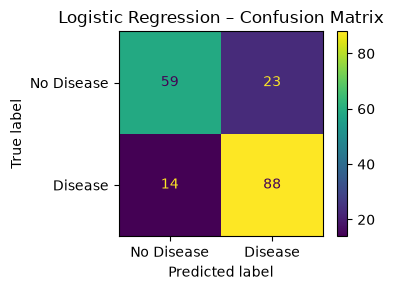

In [42]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=['No Disease', 'Disease']))
print(f"AUC-ROC: {lr_auc:.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, ax=ax, display_labels=['No Disease', 'Disease']
)
ax.set_title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

**What I see:** Logistic Regression gets 80% accuracy and an AUC-ROC of 0.891 — well above the 55.4% baseline. Disease recall is 0.86, meaning it catches 86% of actual cases. The false negatives (real disease predicted as healthy) are the number I care about most in a medical problem.

### Model 2 — Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

  No Disease       0.78      0.76      0.77        82
     Disease       0.81      0.82      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184

AUC-ROC: 0.903


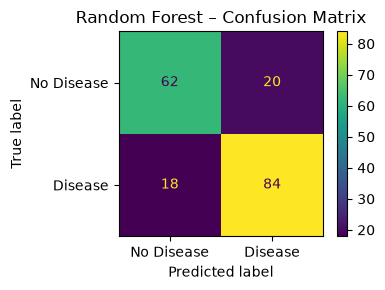

In [43]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_probs)

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['No Disease', 'Disease']))
print(f"AUC-ROC: {rf_auc:.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, ax=ax, display_labels=['No Disease', 'Disease']
)
ax.set_title("Random Forest – Confusion Matrix")
plt.tight_layout()
plt.show()

**What I see:** Random Forest has slightly lower accuracy (79.3% vs 80%) and lower disease recall (0.82 vs 0.86), but wins on AUC-ROC (0.903 vs 0.891). The two models are close — the comparison table below shows the full picture.

### ROC Curve — Both Models

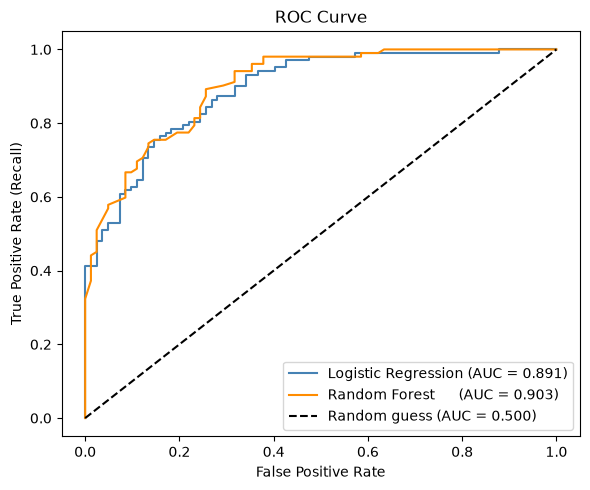

In [44]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_auc:.3f})", color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest      (AUC = {rf_auc:.3f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label="Random guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

The ROC curve shows both models have real predictive power across all thresholds — not just the default 0.5. Random Forest's curve sits consistently higher, confirming it's the stronger model overall.

### Feature Importances (Random Forest)

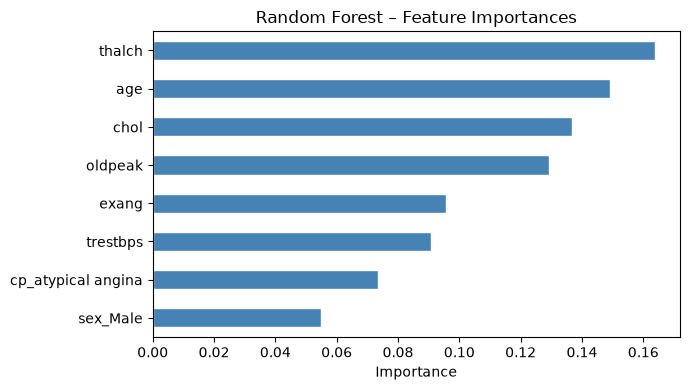

thalch                0.164
age                   0.149
chol                  0.137
oldpeak               0.129
exang                 0.096
trestbps              0.091
cp_atypical angina    0.073
sex_Male              0.055
dtype: float64


In [45]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.head(8).sort_values().plot(
    kind='barh', figsize=(7, 4), color='steelblue', edgecolor='white'
)
plt.title("Random Forest – Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(feat_imp.head(8).round(3))

`thalch` (max heart rate), `age`, `chol` (cholesterol), and `oldpeak` (ST depression) are the top predictors — which lines up with what the correlation analysis showed earlier and makes medical sense.

---

## Model Comparison

In [46]:
results = pd.DataFrame({
    'Model':      ['Baseline (majority)', 'Logistic Regression', 'Random Forest'],
    'Accuracy':   [
        round(baseline_acc, 3),
        round(accuracy_score(y_test, lr_preds), 3),
        round(accuracy_score(y_test, rf_preds), 3)
    ],
    'F1 (macro)': [
        '—',
        round(f1_score(y_test, lr_preds, average='macro'), 3),
        round(f1_score(y_test, rf_preds, average='macro'), 3)
    ],
    'AUC-ROC': ['—', round(lr_auc, 3), round(rf_auc, 3)]
})

print(results.to_string(index=False))

              Model  Accuracy F1 (macro) AUC-ROC
Baseline (majority)     0.554          —       —
Logistic Regression     0.799      0.794   0.891
      Random Forest     0.793       0.79   0.903


---

## Model Selection

**Selected model: Random Forest**

Both models beat the baseline (55.4%), so both learned something real. The accuracy is almost identical — 80% vs 79.3% — so that number alone doesn't decide it. What tips it toward Random Forest is the AUC-ROC: 0.903 vs 0.891. AUC measures how well the model ranks patients across all thresholds, not just 0.5, and that difference is meaningful.

One thing worth noting: at the default threshold, LR actually has higher recall (0.86 vs 0.82). If I were deploying this as a screening tool and wanted to catch as many cases as possible, I'd consider lowering Random Forest's threshold — but for this baseline comparison, Random Forest is the stronger overall model.

---

## Summary

Starting from raw data: 920 patients, 16 columns, missing values everywhere, and a target column that needed binarising before I could even frame the problem.

After cleaning and imputation I trained two models. Logistic Regression and Random Forest ended up close — the real difference showed up in AUC, not accuracy. Random Forest holds up better across thresholds, which matters more than a single number at 0.5.

Final result: Random Forest — 79.3% accuracy, 0.903 AUC-ROC, well above the 55.4% baseline.

**Known limitation:** Missing value imputation was applied before the train/test split, which is a minor form of data leakage. In a production pipeline, imputation statistics should be computed on the training set only.